# GS55 — Step 1: Cell-type distribution analysis

Reads the CODA-labelled GeoJSONs produced by Step 0, counts nuclei per
cell type per slide, and exports summary CSVs used by Step 2.

| Cell | Purpose |
|------|---------|
| 1 | Imports |
| **2** | **Parameters ← edit here** |
| 3 | Load & count |
| 4 | Statistics table |
| 5 | Plots |
| 6 | Export CSVs |

---
## 1 · Imports

In [4]:
import sys
from pathlib import Path
from collections import Counter
import json
import seaborn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd()))
from dataset_utils import extract_cell_types_from_geojson, normalize_slide_stem

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)
print("Imports OK")

Imports OK


---
## 2 · Parameters  ← edit here

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────────
GEOJSON_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\geojson_CODAclass")
OUT_DIR     = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Optional filters ───────────────────────────────────────────────────────────
# Leave empty to process every slide; fill with slide IDs to restrict.
FILTER_SLIDE_IDS  = []
EXCLUDE_CELL_TYPES = ["Unassigned", "OutsideMask"]

print(f"GeoJSON dir : {GEOJSON_DIR}  (exists: {GEOJSON_DIR.exists()})")
print(f"Output dir  : {OUT_DIR}")

GeoJSON dir : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\geojson_CODAclass  (exists: True)
Output dir  : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis


---
## 3 · Load data

In [6]:
# ── Load all GeoJSON files ─────────────────────────────────────────────────────
gj_files = sorted(GEOJSON_DIR.glob("*.geojson"))
if not gj_files:
    raise FileNotFoundError(f"No GeoJSON files in {GEOJSON_DIR}")

if FILTER_SLIDE_IDS:
    gj_files = [f for f in gj_files if normalize_slide_stem(f) in FILTER_SLIDE_IDS]

print(f"Processing {len(gj_files)} slides")

rows = []
errors = []
for gj_path in tqdm(gj_files, desc="Extracting cell types"):
    slide_id = normalize_slide_stem(gj_path)
    counts = extract_cell_types_from_geojson(gj_path)
    if not counts:
        errors.append(gj_path.name)
        continue
    for cell_type, count in counts.items():
        if cell_type not in EXCLUDE_CELL_TYPES:
            rows.append({"slide_id": slide_id, "cell_type": cell_type, "count": count})

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No cell data extracted — check GEOJSON_DIR and EXCLUDE_CELL_TYPES.")

total_cells = df["count"].sum()
n_slides    = df["slide_id"].nunique()
print(f"Slides: {n_slides}  |  Cell types: {df['cell_type'].nunique()}  |  Total cells: {total_cells:,}")
if errors:
    print(f"Skipped {len(errors)} files with no cells: {errors[:5]}")
display(df.head())

Processing 14 slides


Extracting cell types:   0%|          | 0/14 [00:00<?, ?it/s]

Slides: 14  |  Cell types: 19  |  Total cells: 19,389,206


,slide_id,cell_type,count
0,monkey_fetus_GS55_0001,nontissue,94976
1,monkey_fetus_GS55_0001,heart,37330
2,monkey_fetus_GS55_0001,collagen,639807
3,monkey_fetus_GS55_0001,bladder,2906
4,monkey_fetus_GS55_0001,skull,37206


---
## 4 · Statistics

In [7]:
# ── Overall cell-type distribution ────────────────────────────────────────────
cell_type_totals = df.groupby("cell_type")["count"].sum().sort_values(ascending=False)

print(f"{'Cell Type':<25} {'Count':>12} {'Percentage':>12}")
print("-" * 55)
for ct, cnt in cell_type_totals.items():
    print(f"{ct:<25} {cnt:>12,} {cnt/total_cells*100:>11.2f}%")

# ── Per-slide pivot table ──────────────────────────────────────────────────────
pivot_df = (
    df.pivot_table(index="slide_id", columns="cell_type", values="count",
                   fill_value=0, aggfunc="sum")
)
pivot_df["TOTAL"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values("TOTAL", ascending=False)
print(f"\nPivot table: {pivot_df.shape[0]} slides × {pivot_df.shape[1]-1} cell types")
display(pivot_df.head(10))

Cell Type                        Count   Percentage
-------------------------------------------------------
collagen                     8,528,692       43.99%
brain                        4,282,881       22.09%
liver                        2,183,804       11.26%
bone                         1,470,258        7.58%
nontissue                      786,130        4.05%
lungs                          534,154        2.75%
skull                          476,917        2.46%
GI                             383,685        1.98%
heart                          178,606        0.92%
eye                            137,996        0.71%
kidney                         111,204        0.57%
spleen                          73,773        0.38%
thymus                          72,540        0.37%
mesokidney                      50,315        0.26%
thyroid                         46,389        0.24%
ear                             28,860        0.15%
pancreas                        25,421        0.13%
bladder 

cell_type,GI,bladder,bone,brain,collagen,ear,eye,heart,kidney,liver,lungs,mesokidney,nontissue,pancreas,skull,spleen,spleen2,thymus,thyroid,TOTAL
slide_id,,,,,,,,,,,,,,,,,,,,
monkey_fetus_GS55_0031,77893,1855,143506,604011,661265,1410,8,34155,1264,236754,74446,4130,120667,8308,42621,12597,9,14600,3681,2043180
monkey_fetus_GS55_0076,50758,1628,153556,463894,690379,184,0,19811,17207,292647,111997,7976,102801,4159,37364,14213,23,3127,3392,1975116
monkey_fetus_GS55_0001,59711,2906,145203,662015,639807,266,0,37330,547,205168,37952,8633,94976,2523,37206,217,413,20198,9480,1964551
monkey_fetus_GS55_0091,35391,1398,143115,456597,705513,474,526,19817,19031,304818,110939,7816,89296,2963,39359,13192,0,3562,1544,1955351
monkey_fetus_GS55_0121,39796,1159,118007,375878,807248,3859,34336,9946,21800,315371,69213,4217,77974,1684,36660,11403,0,10335,4797,1943683
monkey_fetus_GS55_0061,50170,1554,150105,479423,655373,2037,2,22353,13000,268617,92762,6941,98467,5702,42724,13279,5,3197,4587,1910298
monkey_fetus_GS55_0151,15931,973,129535,421787,742397,9965,14796,3944,18105,290331,35790,6245,42436,0,37627,7560,0,6658,3718,1787798
monkey_fetus_GS55_0181,13161,1469,125237,337699,731074,5436,13760,2261,13172,192369,196,390,39384,0,42668,1284,7,5126,2211,1526904
monkey_fetus_GS55_0211,12248,1687,111368,292263,752285,3413,13132,6584,5899,36798,15,1807,37021,49,28529,25,0,1643,2903,1307669


---
## 5 · Plots

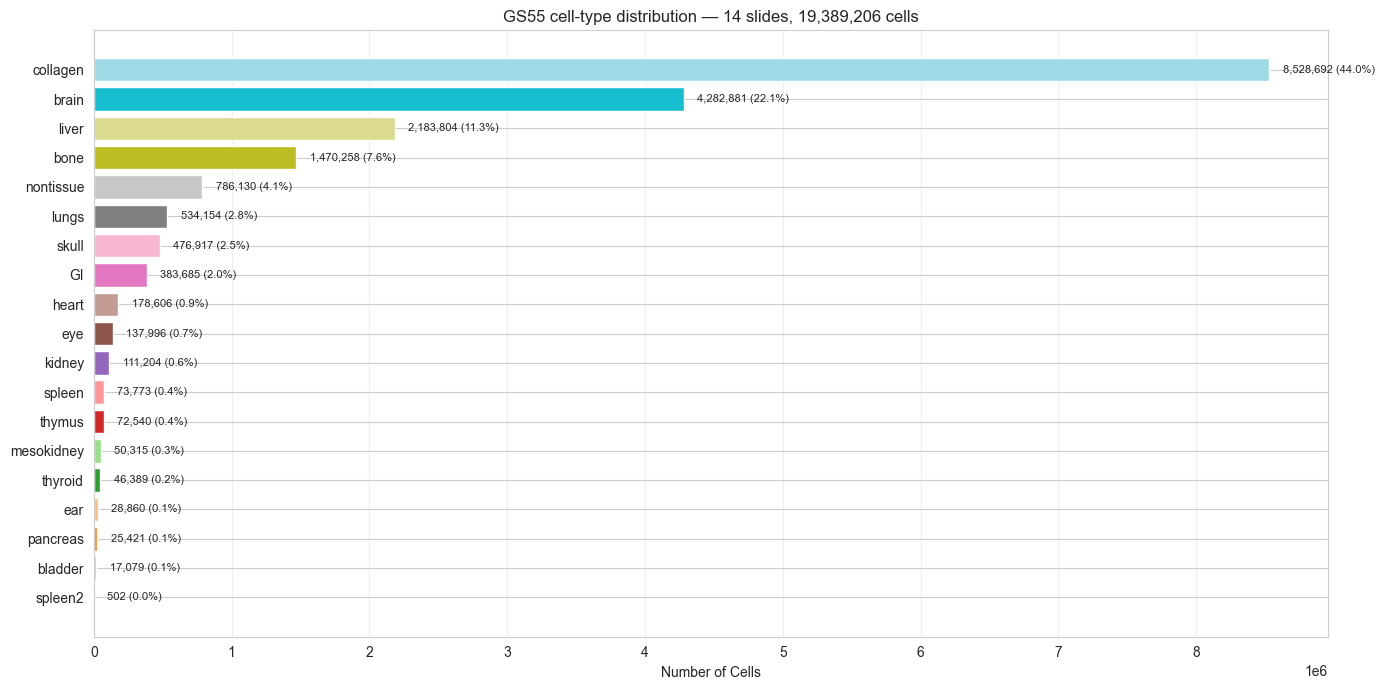

Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis\01_cell_type_distribution_overall.png


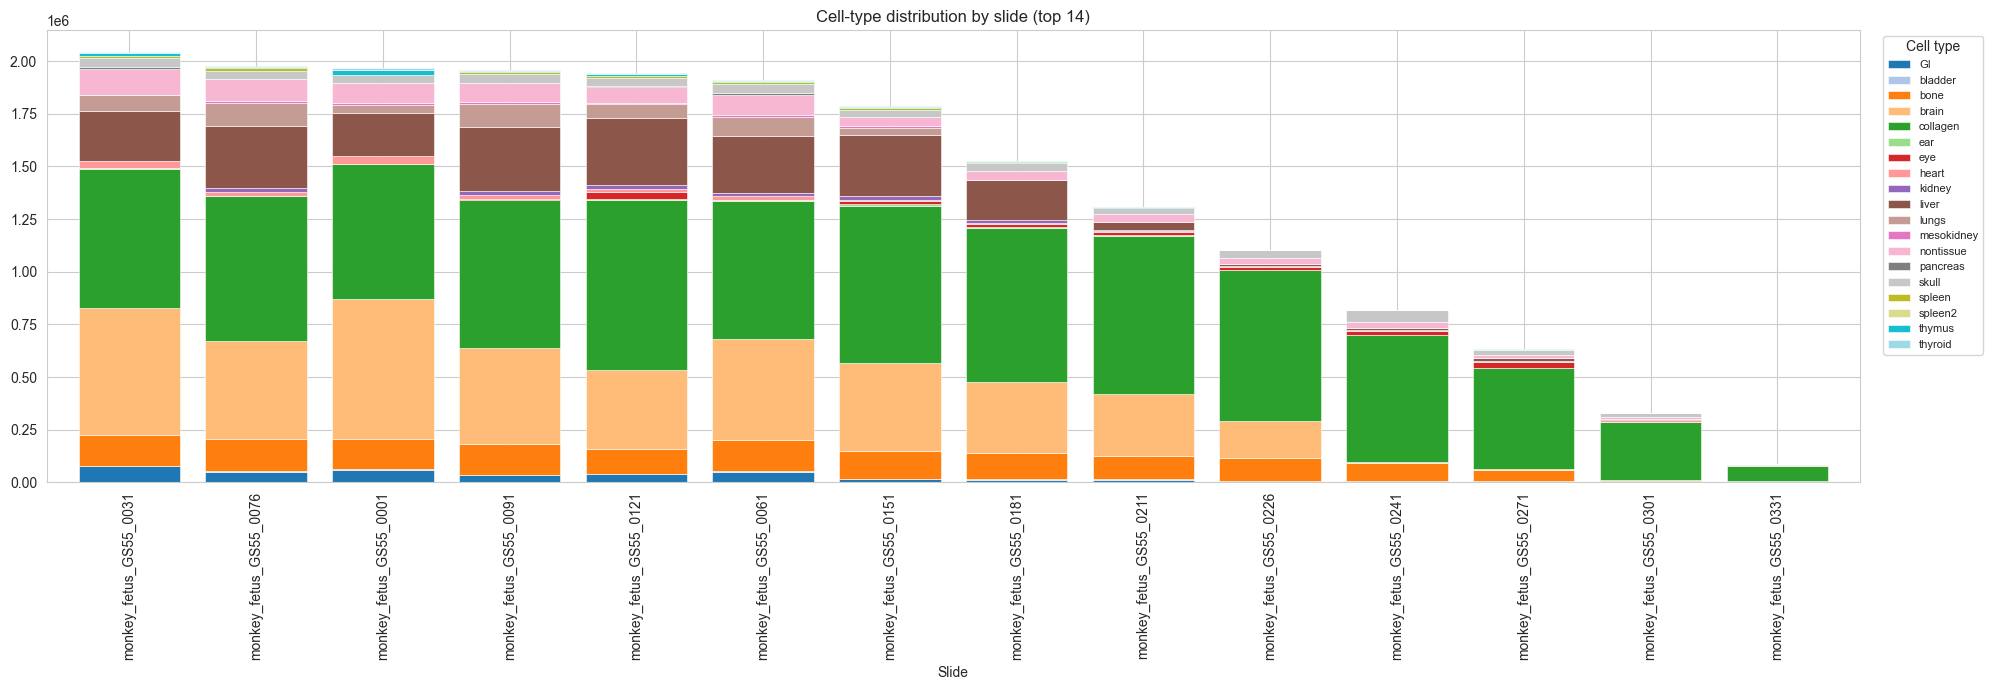

Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis\02_cell_type_distribution_per_slide.png


In [8]:
# ── Overall bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ct_sorted = cell_type_totals.sort_values(ascending=True)
colors    = plt.cm.tab20(np.linspace(0, 1, len(ct_sorted)))
ax.barh(ct_sorted.index, ct_sorted.values, color=colors)
for i, (ct, cnt) in enumerate(ct_sorted.items()):
    ax.text(cnt + total_cells * 0.005, i, f"{cnt:,} ({cnt/total_cells*100:.1f}%)", va="center", fontsize=8)
ax.set_xlabel("Number of Cells"); ax.set_title(f"GS55 cell-type distribution — {n_slides} slides, {total_cells:,} cells")
ax.grid(axis="x", alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / "01_cell_type_distribution_overall.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / '01_cell_type_distribution_overall.png'}")

# ── Per-slide stacked bar (top 40 slides) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 7))
top_n    = min(40, len(pivot_df))
plot_df  = pivot_df.drop(columns=["TOTAL"]).head(top_n)
plot_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.8,
             edgecolor="white", linewidth=0.4)
ax.set_title(f"Cell-type distribution by slide (top {top_n})"); ax.set_xlabel("Slide")
ax.legend(title="Cell type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=90); plt.tight_layout()
plt.savefig(OUT_DIR / "02_cell_type_distribution_per_slide.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / '02_cell_type_distribution_per_slide.png'}")

---
## 6 · Export CSVs

In [9]:
# ── Export CSVs ────────────────────────────────────────────────────────────────
pivot_df.to_csv(OUT_DIR / "cell_counts_per_slide.csv")
df.to_csv(OUT_DIR / "cell_counts_detailed.csv", index=False)

summary = pd.DataFrame({
    "cell_type":       cell_type_totals.index,
    "total_count":     cell_type_totals.values,
    "percentage":      (cell_type_totals.values / total_cells * 100).round(2),
}).reset_index(drop=True)
summary.to_csv(OUT_DIR / "cell_type_summary.csv", index=False)

slide_totals = df.groupby("slide_id")["count"].sum().sort_values(ascending=False)
slide_summary = pd.DataFrame({"slide_id": slide_totals.index, "total_cells": slide_totals.values})
slide_summary.to_csv(OUT_DIR / "slide_summary.csv", index=False)

print("Saved:")
for f in ["cell_counts_per_slide.csv", "cell_counts_detailed.csv",
          "cell_type_summary.csv", "slide_summary.csv"]:
    print(f"  {OUT_DIR / f}")

print(f"\nTop 5 cell types:")
for i, (ct, cnt) in enumerate(cell_type_totals.head(5).items(), 1):
    print(f"  {i}. {ct}: {cnt:,} ({cnt/total_cells*100:.2f}%)")

Saved:
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis\cell_counts_per_slide.csv
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis\cell_counts_detailed.csv
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis\cell_type_summary.csv
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS55\cellvit_training\cell_type_analysis\slide_summary.csv

Top 5 cell types:
  1. collagen: 8,528,692 (43.99%)
  2. brain: 4,282,881 (22.09%)
  3. liver: 2,183,804 (11.26%)
  4. bone: 1,470,258 (7.58%)
  5. nontissue: 786,130 (4.05%)
